## WALKTHROUGH CASE 4

In [1]:
#Loading in the Data
import pandas as pd
card = pd.read_csv("bursztyn2018_experiment1.csv",
sep = ",")
card = card.dropna()

In [2]:
card.head()

,decision,Gold_benefits,Platinum_upgrade,Platinum_upgrade_merit,age,female,income,group
0,0.0,0,0,1,30.333334,0,60000000,2.0
1,0.0,1,0,0,38.250000,0,60000000,0.0
2,0.0,0,0,1,59.333332,0,195000000,2.0
3,0.0,0,0,1,40.500000,0,60000000,2.0
4,0.0,0,1,0,49.916668,0,60000000,1.0


In [3]:
#Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


### Concept Behind The Visualisation
#### Before trusting any experiment, you check that the three groups look similar to each other. 
#### If the Platinum group happened to contain much wealthier or older people 
#### Any difference in acceptance could be due to that — not the card label. Visualizations give you a quick intuitive check.

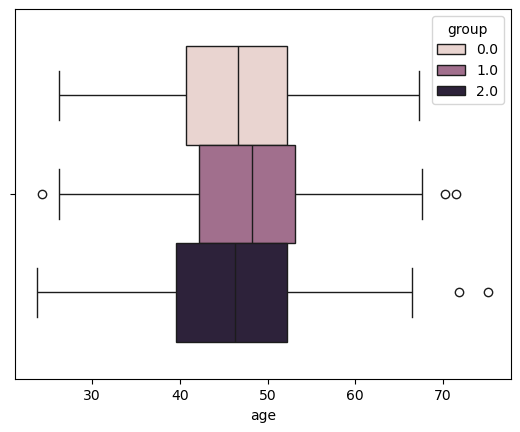

In [4]:
#Visualization for Age
sns.boxplot(x="age", hue="group", data=card)
#boxplot shows the spread of the age among the groups: control, platinum_upgrade, platinum_upgrade_merit
plt.show()
#There's no major difference in age among the groups

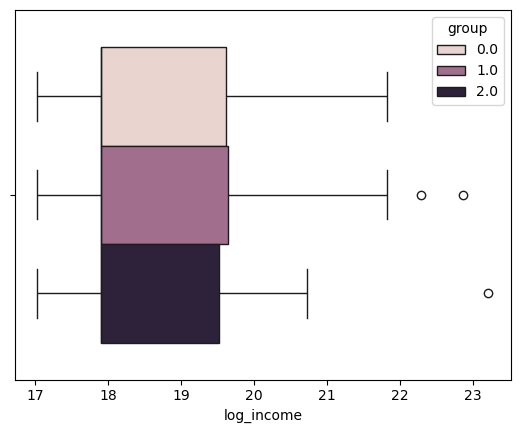

In [5]:
#Visualization for Income
card["log_income"] = np.log(card["income"])
#We are taking the logarithm because of the fluctuation of the data
sns.boxplot(x="log_income", hue="group", data=card)
#hue → how you split the data into subgroups and color them differently on the same axes.
plt.show()
#There's no relative difference accross groups

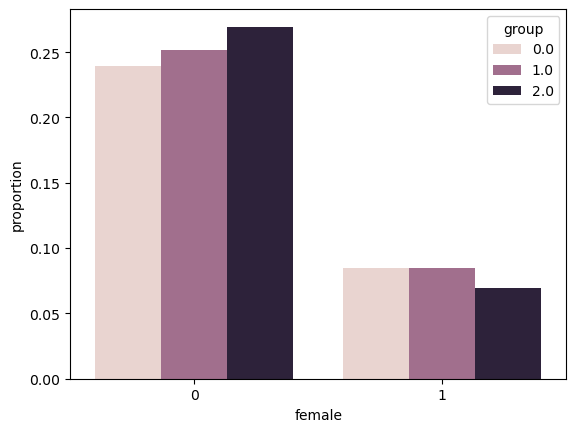

In [6]:
#Visualization for Sex
sns.countplot(x="female", hue="group", data=card, stat="proportion")
#A countplot shows bars for how many people fall into each category.
#Intuitively, stat="proportion" answers: “Out of this category, what fraction belongs to each group?” instead of “How many rows are in each group?”
plt.show()
# The proportions look similar across groups — consistent with random assignment.

### Concept Behind Testing Age
#### Here we test whether the average age is statistically the same in the control group and Treatment 1.
#### Hypotheses: 
##### H₀: average age in control = average age in Treatment 1 (no difference) 
##### Hₐ: they are different

In [7]:
from scipy import stats

In [8]:
#Start by creating the groups: Control and Treatment1
age0 = card.query("group==0")["age"] #This would be the control group
age1 = card.query("group==1")["age"] #This wolud be the treatment 1 group
# What each syntax does:
# 1. card.query("group==0") filters the table to only rows where group equals 0 (the control group)
# 2. ["age"] then picks out just the age column from those rows

In [9]:
#Now that we have the groups together now lets calculate:
test1 = stats.ttest_ind(age0, age1, alternative="two-sided")
#What each syntax means:
# ttest_ind compares the means of two independent groups
# alternative="two-sided"` means we're asking "are they different in either direction?"

In [10]:
print(test1)
#The result of the test came out and we got:
# p-value = 0.13, this is greater than the significance level 0.05
                # thus we don't have strong evidence to reject null hypothesis
#This means that the ages appear to be equal across the two groups

TtestResult(statistic=np.float64(-1.5137850444267564), pvalue=np.float64(0.1306547839848787), df=np.float64(550.0))


### Concept behind testing Income
#### Same concept as testing the Age, but different hypothesis.
#### Hypothesis:
##### H₀: average income in control = average income in Treatment 1
##### Hₐ: they are different

In [11]:
income0 = card.query("group==0")["income"] #Controlled group for income
income1 = card.query("group==1")["income"] #Treatment1 group for income

In [12]:
test2 = stats.ttest_ind(income0, income1, alternative= "two-sided")

In [13]:
print(test2)
# During the test the results gave us the following:
# p-value = 0.38, greater than the significance level of 0.05.
    #We don't have strong evidence to reject null hypothesis
#This just means that income appeared to be equal accross groups

TtestResult(statistic=np.float64(-0.8769509203085059), pvalue=np.float64(0.38089617114303986), df=np.float64(550.0))


### Concepts behind Proportion of Females
#### Sex is a yes/no variable (female = 1 or 0), so we can't compare averages — we compare proportions. 
#### Specifically, is the share of female customers the same in both groups?
#### Hypotheses:
##### H₀: proportion of females in control = proportion of females in Treatment 1
##### Hₐ: they are different

In [14]:
female0 = card.query("group==0")["female"]
female1 = card.query("group==1")["female"]

In [15]:
from statsmodels.stats.proportion import test_proportions_2indep

test3 = test_proportions_2indep(
    count1 = female0.sum(), #The number of female in control
    nobs1 = female0.size,   #The number of people in control
    count2 = female1.sum(), #The number of female in treatment 1
    nobs2 = female1.size, #The number of people in treatment 1
    alternative = "two-sided"
)
#Explaination of a line and syntax.
# test_proportions_2indep means compare the proportion of 'successes' in group A vs Group B
    #Then test if they are statistically different.
# count1 — how many females are in Group 1. (`.sum()` adds up all the 1s in the female column)
# nobs1  — total number of people in Group 1 (`.size` counts all rows)

In [16]:
print(test3)
#Through the test we got the following results:
# p-value = 0.80, which is greater than 0.05.
    # We don't have strong evidence to reject null hypothesis
# the difference between groups is highlighted by the statistics which is 0.251
    # This just means there's no major difference

statistic = 0.2507256026768035
pvalue = 0.8020262647342524
compare = diff
method = agresti-caffo
diff = 0.009323580780291774
ratio = 1.03690036900369
odds_ratio = 1.0499999999999998
variance = 0.0013815590749122455
alternative = two-sided
value = 0
tuple = (np.float64(0.2507256026768035), np.float64(0.8020262647342524))


### Replicating the results, Question 6
#### The concept: Now we get to the actual research question. 
#### Did the Platinum label cause more people to accept the card? 
#### We run two tests: Control vs. Treatment 1, and Treatment 1 vs. Treatment 2.

In [17]:
card["group"].value_counts()
#This allows us to check what value exist in a column named "group"

group
2.0    283
1.0    281
0.0    271
Name: count, dtype: int64

In [18]:
card["decision"].value_counts()
#This allows us to check what values decision has.
# 0 = means no
# 1 = means yes

decision
0.0    674
1.0    161
Name: count, dtype: int64

In [19]:
#Lets create the groups: Control, Treatment 1, Treatment 2
control = card.query("group==0")["decision"] # The controlled groups decisions
treatment1 = card.query("group==1")["decision"] #The treatment 1 decisions
treatment2 = card.query("group==2")["decision"] #The treatment 2 decisions

In [20]:
from statsmodels.stats.proportion import test_proportions_2indep

In [21]:
test4 = test_proportions_2indep(
    count1= control.sum(),
    nobs1= control.size,
    count2 = treatment1.sum(),
    nobs2= treatment1.size,
    alternative = "two-sided"
)

In [ ]:
print(test4)
#Comparing the Controlled group with Treatment 1 results:
# p-value = 0.02, this is less than the significance level of 0.05.
    # Therefore, we can conclude that there's a differenc between the control and the treament group
# diff = -0.073
    # This results tells us that the Platinum has 7.3% higher points than the controlled. 

statistic = -2.2698350967190306
pvalue = 0.02321759024486838
compare = diff
method = agresti-caffo
diff = -0.07343304749773474
ratio = 0.6502595534429921
odds_ratio = 0.5949587136027815
variance = 0.0010292305692636101
alternative = two-sided
value = 0
tuple = (np.float64(-2.2698350967190306), np.float64(0.02321759024486838))


In [24]:
test5 = test_proportions_2indep (
    count1 = treatment1.sum(),
    nobs1 = treatment1.size,
    count2 = treatment2.sum(),
    nobs2 = treatment2.size,
    alternative= "two-sided"
)

In [ ]:
print(test5)
# The result in the comparison of treatment 1 and treatment 2 are the following:
# p-value = 0.57, this is greater than the significance level of 0.05
    # Thus, in this case we don't have strong evidence to reject null hypothesis
# diff = -0.02
    # This means that there's treatment 2 has a higher points by 2% than treatment 1

statistic = -0.5613552287954601
pvalue = 0.5745553985183316
compare = diff
method = agresti-caffo
diff = -0.019717565987198676
ratio = 0.9141527511634273
odds_ratio = 0.8913374913374914
variance = 0.001214719105107244
alternative = two-sided
value = 0
tuple = (np.float64(-0.5613552287954601), np.float64(0.5745553985183316))


## Explaination of what Permutation Test, Question 7
##### The permutation test is an alternative way to get a p-value that makes fewer mathematical assumptions. 
##### Here is the logic: "If the card label truly had no effect (H₀ is true), then it shouldn't matter which customer got which label — the outcomes would be the same either way. So let's pretend we re-ran the experiment thousands of times by randomly reassigning labels and see how often we get a difference as large as the one we actually observed."

### Steps on how to do it:
##### 1. Combine all customers from both groups into one pool
##### 2. Record the real observed difference in acceptance rates — this is your benchmark
##### 3. Randomly shuffle who gets label "A" vs. "B" — this simulates a world where the label had no effect
##### 4. Calculate the difference in acceptance rates for this fake assignment
##### 5. Repeat 10,000 times to build up a picture of what "random chance" looks like
##### 6. Count what fraction of those 10,000 random differences are as large or larger than your real observed difference — that fraction is your p-value

In [ ]:
#Main differences between bootstrap and permutation test
# Permutation: resample labels → “what would we see if the treatment truly did nothing?” (hypothesis test). 
# Bootstrap: resample data → “how uncertain is our estimate in the real world?” (estimation / CIs).

## Implementation of Permutation Test


In [27]:
#Creation of Groups
groupA = control
groupB = treatment1

#Step 1: Combining the groups
data = np.concatenate([groupA, groupB]) 
        #np.concatenate(...) — NumPy's function for joining arrays end-to-end
        #[group_A, group_B] — the two arrays you want to join, wrapped in square brackets
# What this does:
# Merges both groups into one single combined list of decisions. 
# Think of it like physically combining two stacks of cards into one big pil